In [1]:
# GRADIENT BOOSTING ÖZET:
# - Nedir?: Hatalarından ders çıkaran zayıf karar ağaçlarını peş peşe dizerek çalışan güçlü bir algoritmadır.
# - Nasıl Çalışır?: Her yeni ağaç, bir önceki ağacın yaptığı HATAYI (residual) tahmin etmek için eğitilir.
# - Neden Kullanılır?: Tablosal verilerde (regresyon/sınıflandırma) çok yüksek tahmin başarısı verir.
# - Ne Zaman?: Karmaşık tablosal verilerde yüksek doğruluk gerektiğinde ve XGBoost/LightGBM gibi gelişmiş modellere geçiş adımı olarak kullanılır.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv('18-concrete_data.csv')

In [4]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [7]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
# cimento yaparken her bilesen olmak zorunda degildir bir uzmana danismak lazim bundan doalyi sifir olan yerler oladabilir olmayada bilir 
# bundan dolayi sifirli yerleri ellemiyecem

In [9]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [10]:
df.corr()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
Cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
Blast Furnace Slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
Fly Ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
Water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
Superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
Coarse Aggregate,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
Fine Aggregate,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
Age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
Strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


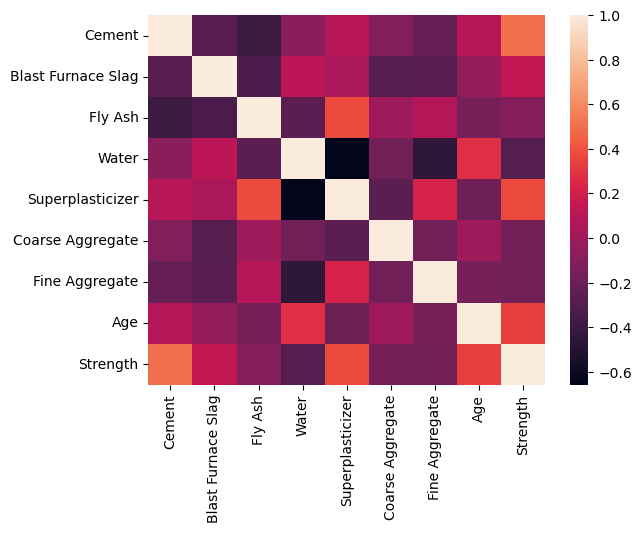

In [11]:
sns.heatmap(df.corr())
plt.show()

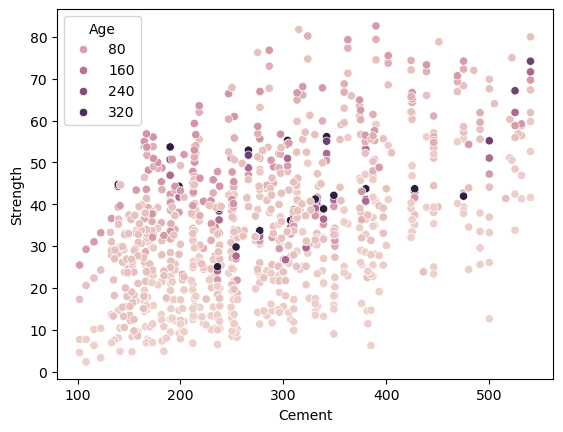

In [12]:
sns.scatterplot(data=df,x='Cement',y='Strength',hue='Age')
plt.show()

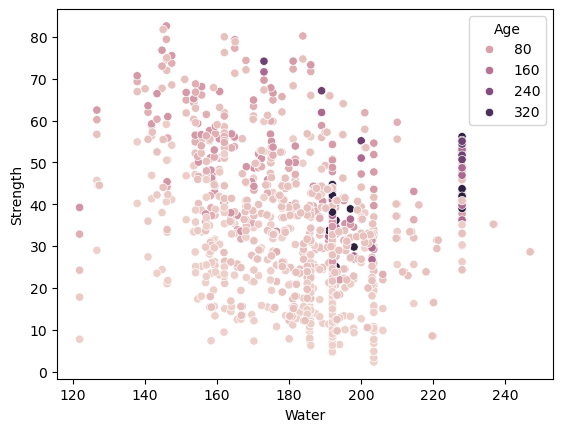

In [13]:
sns.scatterplot(data=df,x='Water',y='Strength',hue='Age')
plt.show()

In [14]:
X = df.drop('Strength',axis=1)
y = df['Strength']

In [15]:
from sklearn.model_selection import train_test_split 

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [17]:
# Greading boosting manuel yapma

In [18]:
from sklearn.tree import DecisionTreeRegressor

In [19]:
# first weak learner
tree_reg1 = DecisionTreeRegressor(max_depth=3)
tree_reg1.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=3)

In [20]:
y2 = y_train - tree_reg1.predict(X_train) # X_train datamiz icin r2 scorumuzu hesapladik 

In [21]:
y2[:5]

919   -15.044359
641    -2.967000
535     2.098039
835   -10.123407
583    -2.334359
Name: Strength, dtype: float64

In [22]:
#  second weak learner

In [23]:
tree_reg2 = DecisionTreeRegressor(max_depth=4)
tree_reg2.fit(X_train,y2)

DecisionTreeRegressor(max_depth=4)

In [24]:
y3 = y2 - tree_reg2.predict(X_train)
y3[:5]

919   -7.776773
641   -0.353441
535    9.365625
835   -4.303430
583   -3.033962
Name: Strength, dtype: float64

In [25]:
# daha da dusurduk 

In [26]:
# thirtd weak learner

In [27]:
tree_reg3 = DecisionTreeRegressor(max_depth=4)
tree_reg3.fit(X_train,y3)

DecisionTreeRegressor(max_depth=4)

In [28]:
y4 = y3 - tree_reg3.predict(X_train)
y4[:5]

919   -8.311212
641   -0.887880
535    8.831186
835   -0.209931
583   -0.406351
Name: Strength, dtype: float64

In [29]:
# yavas yavas optimallige dogru gidiyoruz azaltip arttirarak

In [30]:
for tree in (tree_reg1,tree_reg2,tree_reg3):
    print(tree.predict(X_train))

[40.14435897 15.697      46.75196078 25.54340659 40.14435897 40.14435897
 40.14435897 15.697      40.14435897 15.697      40.14435897 25.54340659
 40.14435897 64.07125    40.14435897 40.14435897 40.14435897 40.14435897
 40.14435897 46.75196078 40.14435897 40.14435897 40.14435897 64.07125
 46.75196078 27.71878049 40.14435897 46.75196078 40.97088889 40.14435897
 64.07125    15.697      46.75196078 15.697      40.14435897 15.697
 40.14435897 15.697      25.54340659 40.14435897 40.14435897 40.14435897
 25.54340659 15.697      40.14435897 15.697      15.697      40.97088889
 27.71878049 64.07125    40.14435897 15.697      40.14435897 40.14435897
 40.14435897 15.697      40.14435897 15.697      27.30566667 15.697
 64.07125    40.14435897 40.14435897 40.14435897 27.71878049 25.54340659
 25.54340659 15.697      40.14435897 27.71878049 15.697      40.14435897
 46.75196078 40.14435897 15.697      40.14435897 40.14435897 64.07125
 25.54340659 46.75196078 40.14435897 15.697      40.14435897 40.144

In [31]:
# ucunden de gelen y_predleri hesaplamamiz lazimd 

In [32]:
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1,tree_reg2,tree_reg3))

In [33]:
from sklearn.metrics import r2_score

In [34]:
r2_score(y_test,y_pred)

0.8159494658632223

In [35]:
tree_reg4 = DecisionTreeRegressor(max_depth=4)
tree_reg4.fit(X_train,y4)

DecisionTreeRegressor(max_depth=4)

In [36]:
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1,tree_reg2,tree_reg3))

In [37]:
r2_score(y_test,y_pred)

0.8159494658632223

In [38]:
# simdide normak sklearn kullanarak yapalim 

In [39]:
from sklearn.ensemble import GradientBoostingRegressor

In [40]:
gbr = GradientBoostingRegressor(n_estimators=3,learning_rate=0.1)

In [41]:
gbr.fit(X_train,y_train)

GradientBoostingRegressor(n_estimators=3)

In [42]:
y_pred = gbr.predict(X_test)
r2_score(y_test,y_pred)

0.31671418229216797

In [43]:
gbr = GradientBoostingRegressor(n_estimators=100,max_depth=3,learning_rate=0.1)

In [44]:
gbr.fit(X_train,y_train)
y_pred =gbr.predict(X_test)
r2_score(y_test,y_pred)

0.9247306198159041

In [45]:
# hyperparametre tuning 

In [46]:
params = {
    'n_estimators':[100,150,200],
    'max_depth': [3,4,5],
    'loss' : ['squared_error','absolute_error','huber','quantile'],
    'learning_rate':[0.01,0.1,0.5]
}

In [47]:
# Gradient Boosting Hiperparametre Sözlüğü (params)
# 1. n_estimators: Modele eklenecek toplam karar ağacı sayısı (100, 150, 200).
# 2. max_depth: Her bir ağacın inebileceği maksimum derinlik/dallanma sınırı (3, 4, 5).
# 3. loss: Modelin hatayı hesaplama yöntemi (MSE, MAE, Huber, Quantile).
# 4. learning_rate: Her yeni ağacın modele katkı oranı / adım boyu (0.01, 0.1, 0.5).
# Özet: Arama algoritmalarının (GridSearch/RandomizedSearch) denerken kullanacağı kombinasyon alanıdır.

In [48]:
from sklearn.model_selection import RandomizedSearchCV

In [49]:
rscv=RandomizedSearchCV(estimator=GradientBoostingRegressor(),param_distributions=params,cv=5)

In [50]:
rscv.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.5],
                                        'loss': ['squared_error',
                                                 'absolute_error', 'huber',
                                                 'quantile'],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 150, 200]})

In [51]:
rscv.best_params_

{'n_estimators': 100, 'max_depth': 5, 'loss': 'huber', 'learning_rate': 0.1}

In [52]:
y_pred = rscv.predict(X_test)
r2_score(y_test,y_pred)

0.9446122049159272

In [53]:
# Greading boosting class

In [54]:
# REGRESSOR vs CLASSIFIER FARKı:
# 1. GradientBoostingRegressor: Sürekli SAYISAL değer tahmini yapar (örn: Araba fiyatı, Sıcaklık, Maaş).
# 2. GradientBoostingClassifier: KATEGORİK sınıflandırma yapar (örn: Spam/Spam değil, Hasta/Sağlıklı, Churn/Kaldı).

In [55]:
df = pd.read_csv('19-heart.csv')

In [56]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [58]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [59]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [60]:
# datamiz bizim icin numeric hale getirilmis 

In [61]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [62]:
# azaltmaya arttirmaya gerek yoktur 

In [63]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


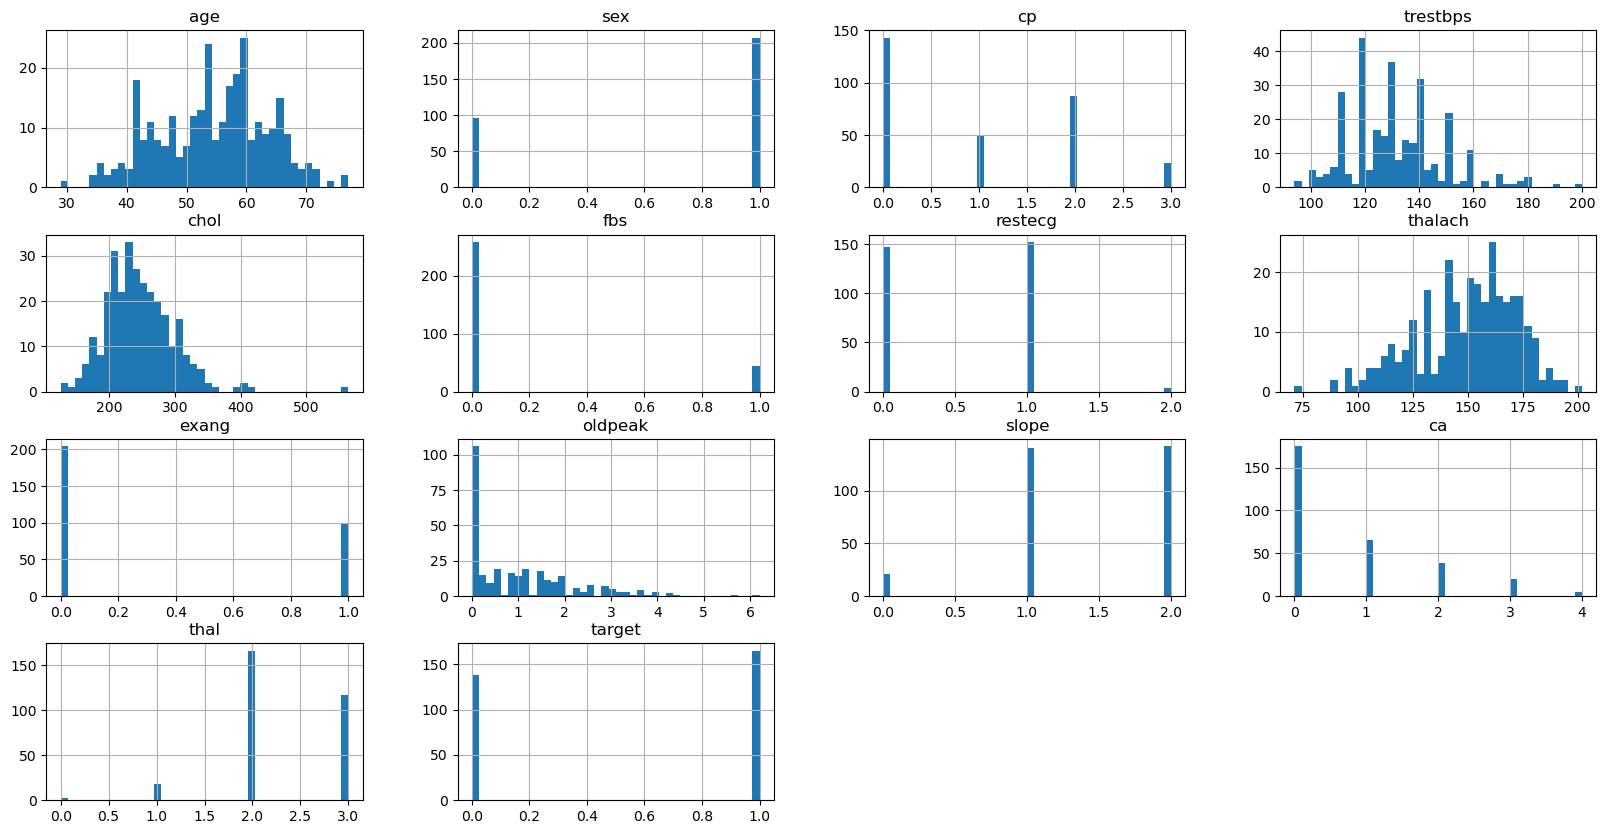

In [64]:
df.hist(bins=40,figsize=(20,10))
plt.show()

In [65]:
X = df.drop('target',axis=1)
y = df['target']

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [70]:
def cor_drop(df, threshold):
    col_drop = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if corr.iloc[i, j] > threshold:
                colname = corr.columns[i]
                col_drop.add(colname)  # columns_drop yerine col_drop yapıldı

    return col_drop
    

In [71]:
# bu kodmuz veri setindeki biribiryle yuksek iliskili (kolaresyon) gereksiz sutunlari tespit etmis olduk 

In [74]:
cor_drop(X_train,0.80)

set()

In [75]:
# herhangi bir kolonu drop etmemize gerek yok 

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV

In [77]:
gb = GradientBoostingClassifier()
gb.fit(X_train,y_train)

GradientBoostingClassifier()

In [79]:
y_pred = gb.predict(X_test)
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.82      0.74      0.78        31
           1       0.76      0.83      0.79        30

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61

[[23  8]
 [ 5 25]]


In [80]:
#  hyperparametre tuning 

In [81]:
parametres = {
    'loss':['log_loss','exponetial'],
    'learning_rate':[0.01,0.5,0.1],
    'n_estimators':[100,150,180,200],
    'max_depth':[3,4,5],
    'subsample':[0.8,1.0]
}

In [83]:
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(),param_grid=parametres,cv=5,n_jobs=-1,verbose=1 )

In [85]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
360 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
193 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.5, 0.1],
                         'loss': ['log_loss', 'exponetial'],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 150, 180, 200],
                         'subsample': [0.8, 1.0]},
             verbose=1)

In [86]:
grid_search.best_params_

{'learning_rate': 0.01,
 'loss': 'log_loss',
 'max_depth': 3,
 'n_estimators': 180,
 'subsample': 0.8}

In [88]:
y_pred = grid_search.predict(X_test)
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.89      0.81      0.85        31
           1       0.82      0.90      0.86        30

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61

[[25  6]
 [ 3 27]]


In [89]:
# accuracy skorumuz % 85 kadar cikarttir gayet iyi bir sonuc 